# 19.1 · Integral images and Haar features

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain integral images and haar features using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[09 · Feature Detection](../../09-feature-detection/README.md), [12 · Contours and Shapes](../../12-contours-and-shapes/README.md), [15 · Video Processing](../../15-video-processing/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Face detection locates face-like regions. It does not identify a person, estimate trustworthiness or infer sensitive traits. Classical and learned detectors use different representations, but all require careful evaluation across pose, lighting, scale and the intended population.

## 2. Intuition

An integral image stores the cumulative sum above and to the left of each position. Rectangle sums then require four array accesses, which makes Haar rectangle features inexpensive. A cascade rejects easy negative windows early and spends more computation on promising regions. Its learned thresholds come from training examples, not the integral-image formula itself.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 19
LESSON = 0
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
S(x,y)=\sum_{u\le x,v\le y}I(u,v)
$$

S is an integral image and I the original intensity. A padded integral image makes rectangle sums uniform. For the 2×2 values [[1,2],[3,4]], the full rectangle sum is 10.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
image = np.array([[1, 2], [3, 4]])
integral = np.pad(image.cumsum(0).cumsum(1), ((1, 0), (1, 0)))
total = integral[2, 2] - integral[0, 2] - integral[2, 0] + integral[0, 0]
assert total == 10
print(total)

10


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The lab visualizes an integral image, orientation histograms and actual cascade boxes. Empty detections are a valid outcome on the synthetic cartoon.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def faces(lesson, seed, amount):
    avatar = np.full((96, 96), 220, np.uint8)
    cv2.ellipse(avatar, (48, 48), (30, 38), 0, 0, 360, 160, -1)
    cv2.circle(avatar, (36, 37), 5, 30, -1)
    cv2.circle(avatar, (61, 37), 5, 30, -1)
    cv2.ellipse(avatar, (48, 62), (15, 7), 0, 0, 180, 30, 2)
    integral = np.pad(avatar.astype(float), ((1, 0), (1, 0))).cumsum(0).cumsum(1)
    region_sum = integral[45, 70] - integral[25, 70] - integral[45, 25] + integral[25, 25]
    cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    if cascade.empty():
        raise FileNotFoundError("OpenCV Haar cascade data missing.")
    boxes = cascade.detectMultiScale(avatar, scaleFactor=1.1, minNeighbors=3)
    features = n.hog(avatar)
    return Result(
        "19 · Integral images, HOG and face detector limits",
        {
            "Synthetic avatar, not a photograph": avatar,
            "Integral image": integral,
            "HOG cell energy": features.sum(2),
        },
        metrics={
            "rectangle_sum_reference": float(region_sum),
            "rectangle_sum_direct": int(avatar[25:45, 25:70].sum()),
            "cascade_boxes_on_cartoon": len(boxes),
        },
        notes="A cartoon is a plumbing test, not an accuracy test for a human-face detector. Use consenting subjects for real evaluation. No identity, age, emotion or sensitive traits are inferred.",
    )

{
  "rectangle_sum_reference": 122940.0,
  "rectangle_sum_direct": 122940,
  "cascade_boxes_on_cartoon": 0
}
A cartoon is a plumbing test, not an accuracy test for a human-face detector. Use consenting subjects for real evaluation. No identity, age, emotion or sensitive traits are inferred.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import hog

display(Code(inspect.getsource(hog), language="python"))

def hog(image, cell_size=8, bins=9):
    """Unsigned orientation histograms per cell, L2 normalized; teaching HOG."""
    gx, gy, magnitude = sobel(image)
    angles = np.mod(np.arctan2(gy, gx), np.pi)
    result = []
    for y in range(0, image.shape[0] - cell_size + 1, cell_size):
        row = []
        for x in range(0, image.shape[1] - cell_size + 1, cell_size):
            sl = np.s_[y : y + cell_size, x : x + cell_size]
            hist, _ = np.histogram(angles[sl], bins=bins, range=(0, np.pi), weights=magnitude[sl])
            row.append(hist / np.sqrt((hist * hist).sum() + 1e-8))
        result.append(row)
    return np.array(result)

## 8. Experiment

Test how resizing and contrast affect a detector on a small consented evaluation set; include empty scenes and partial occlusions.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "rectangle_sum_reference": 122940.0,
    "rectangle_sum_direct": 122940,
    "cascade_boxes_on_cartoon": 0
  },
  "second_seed": {
    "rectangle_sum_reference": 122940.0,
    "rectangle_sum_direct": 122940,
    "cascade_boxes_on_cartoon": 0
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

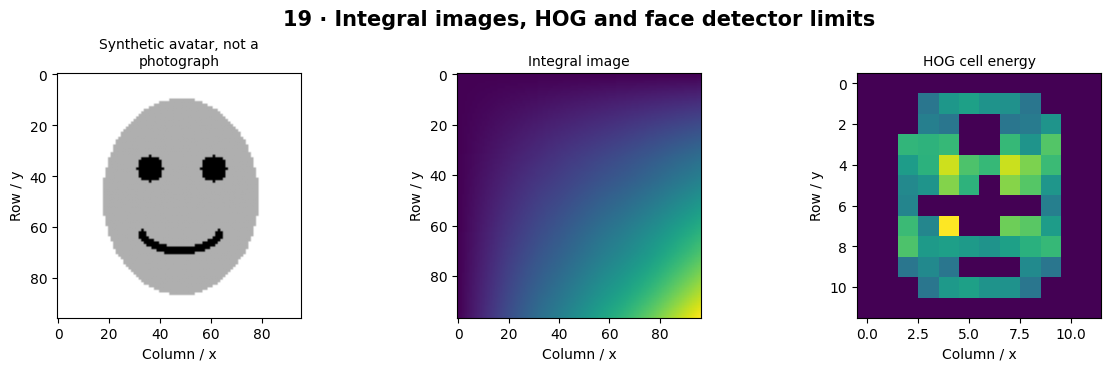

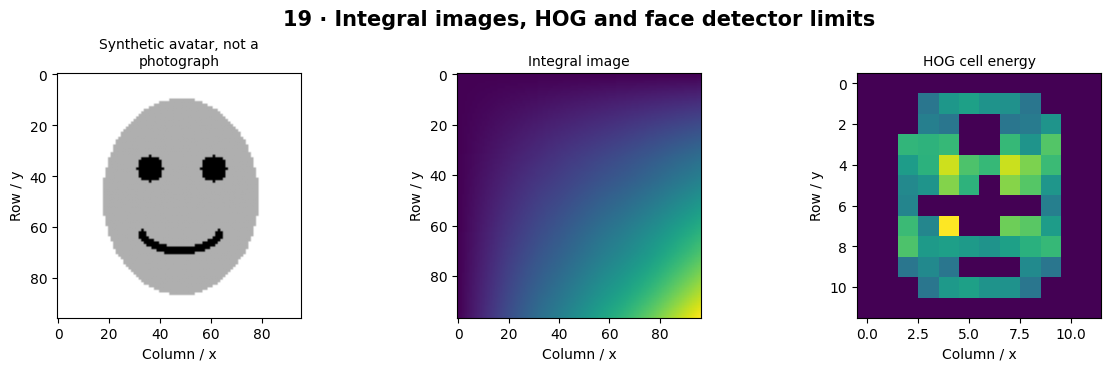

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Consented Face Detection Demo**. Evaluate face boxes on consented examples without identity claims. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

A detected box is not proof that a person is present. Cascade scores should not be treated as calibrated probabilities.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Test how resizing and contrast affect a detector on a small consented evaluation set; include empty scenes and partial occlusions.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a local face-detection viewer with no image retention, annotated false positives and a documented consented evaluation protocol.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

An integral image stores the cumulative sum above and to the left of each position. Rectangle sums then require four array accesses, which makes Haar rectangle features inexpensive. A cascade rejects easy negative windows early and spends more computation on promising regions. Its learned thresholds come from training examples, not the integral-image formula itself.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **HOG and sliding-window detectors** in this chapter.

[Primary reference](https://docs.opencv.org/4.x/db/d28/tutorial_cascade_classifier.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)